<h1 style="
    color: darkblue;
    font-size: 40px;
    text-align: center;
    border: 3px solid darkblue;
    padding: 12px;
    border-radius: 10px;
">
Imports
</h1>

In [2]:
from pipeline.stage_20_band_filtering_and_epoch.band_filtering_and_epoch import run_band_filtering_and_epoch
from pipeline.stage_30_motif_sequence.motif_sequence import run_motif_sequence
from pipeline.stage_40_synchronization_matrix.synchronization_matrix import run_synchronization_matrix
from pipeline.stage_50_maximum_matrix.maximum_matrix import run_maximum_matrix
from pipeline.stage_60_synchronization_matrix_graph_measure.graph_measure import run_synchronization_matrix_graph_measure
from pipeline.stage_70_maximum_matrix_graph_measure.maximum_matrix_graph_measure import run_maximum_matrix_graph_measure
from pipeline.stage_80_lag_based_SVM.lag_based_SVM import run_lag_based_SVM
from pipeline.stage_90_maximum_matrix_based_SVM.maximum_matrix_based_SVM_original_flow import run_maximum_matrix_based_SVM_original_flow

from pipeline.stage_100_generate_results.generate_per_subject_band_wise_effect import run_generate_per_subject_band_wise_effect

from pipeline.stage_100_generate_results_original_flow.generate_confusion_matrix_for_maximum_matrix_original_flow import run_generate_confusion_matrix_for_maximum_matrix_original_flow
from pipeline.stage_100_generate_results_original_flow.generate_band_contributions_across_k_original_flow import plot_band_contributions_across_k_original_flow
from pipeline.stage_100_generate_results_original_flow.generate_topographic_plot_original_flow import plot_topographic_original_flow

<h1 style="
    color: darkblue;
    font-size: 40px;
    text-align: center;
    border: 3px solid darkblue;
    padding: 12px;
    border-radius: 10px;
">
Pipeline
</h1>

<h1 style="color:darkblue; font-size:40px;">
Stage: Initial Preprocessing
</h1>

<p style="color:#444444; font-size:18px;">
In this stage, the raw EEG data from the three sessions of each participant were preprocessed through four steps:
</p>

<ul style="color:#444444; font-size:18px;">
    <li>Re-referencing</li>
    <li>Digital Filtering</li>
    <li>Epoching and Decimation</li>
    <li>Independent Component Analysis (ICA)</li>
</ul>

<p style="color:#444444; font-size:18px;">
This preprocessing was performed by the creators of the <i>Thinking Out Loud</i> dataset. Details can be found in the <i>Data Processing</i> section of the original publication, available on the
<a href="https://www.nature.com/articles/s41597-022-01147-2">website</a>.
A local copy of the paper is available for convenience as a
<a href="./docs/Data_Set_Thinking_Out_Loud.pdf">PDF</a>.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_10_initial_preprocessing/diagrams/stage_10_initial_preprocessing.drawio.svg">diagram</a>.
</p>

<h1 style="color:darkblue; font-size:40px;">
Stage: Band Filtering and Epoching
</h1>

<p style="color:#444444; font-size:18px;">
This stage is responsible for filtering the EEG data obtained from the previous stage into eleven frequency bands, each with a bandwidth of 3 Hz, ranging from 12 Hz to 45 Hz. The resulting frequency bands are (12–15), (15–18), (18–21), ..., (42–45) Hz.
</p>

<p style="color:#444444; font-size:18px;">
The EEG data are also segmented into epochs corresponding to the <i>Action Interval</i>, from 1.5 s to 3.5 s after the cue, following the procedure described in the original publication.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_20_band_filtering_and_epoch/diagrams/band_filtering_and_epoch.drawio.svg">diagram</a>.
</p>

In [19]:
run_band_filtering_and_epoch()


Processando stage_20_band_filtering_and_epoch
sub-01 ses-01...
{'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6, 'A8': 7, 'A9': 8, 'A10': 9, 'A11': 10, 'A12': 11, 'A13': 12, 'A14': 13, 'A15': 14, 'A16': 15, 'A17': 16, 'A18': 17, 'A19': 18, 'A20': 19, 'A21': 20, 'A22': 21, 'A23': 22, 'A24': 23, 'A25': 24, 'A26': 25, 'A27': 26, 'A28': 27, 'A29': 28, 'A30': 29, 'A31': 30, 'A32': 31, 'B1': 32, 'B2': 33, 'B3': 34, 'B4': 35, 'B5': 36, 'B6': 37, 'B7': 38, 'B8': 39, 'B9': 40, 'B10': 41, 'B11': 42, 'B12': 43, 'B13': 44, 'B14': 45, 'B15': 46, 'B16': 47, 'B17': 48, 'B18': 49, 'B19': 50, 'B20': 51, 'B21': 52, 'B22': 53, 'B23': 54, 'B24': 55, 'B25': 56, 'B26': 57, 'B27': 58, 'B28': 59, 'B29': 60, 'B30': 61, 'B31': 62, 'B32': 63, 'C1': 64, 'C2': 65, 'C3': 66, 'C4': 67, 'C5': 68, 'C6': 69, 'C7': 70, 'C8': 71, 'C9': 72, 'C10': 73, 'C11': 74, 'C12': 75, 'C13': 76, 'C14': 77, 'C15': 78, 'C16': 79, 'C17': 80, 'C18': 81, 'C19': 82, 'C20': 83, 'C21': 84, 'C22': 85, 'C23': 86, 'C24': 87, 'C25

<h1 style="color:darkblue; font-size:40px;">
Stage: Motif Sequence
</h1>

<p style="color:#444444; font-size:18px;">
This stage is responsible for extracting the motif sequence from each EEG epoch.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_30_motif_sequence/diagrams/stage_30_motif_sequence.drawio.svg">diagram</a>.
</p>

In [20]:
run_motif_sequence()


Processando stage_30_motif_sequence
sub-01 ses-01...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_30_motif_sequence/sub-01_ses-01_inner_bands_motifs.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_30_motif_sequence/sub-01_ses-01_inner_bands_motifs_labels.npy
Shape dos dados: (80, 11, 128, 510)
Shape dos rótulos: (80,)

Processando stage_30_motif_sequence
sub-01 ses-02...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_30_motif_sequence/sub-01_ses-02_inner_bands_motifs.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_30_motif_sequence/sub-01_ses-02_inner_bands_motifs_labels.npy
Shape dos dados: (80, 11, 128, 510)
Shape dos rótulos: (80,)

Processando stage_30_motif_

<h1 style="color:darkblue; font-size:40px;">
Stage: Synchronization Matrices
</h1>

<p style="color:#444444; font-size:18px;">
This stage computes the synchronization matrix for each motif signal considering lags 0, 1, 2, and 3. Each matrix is normalized using its own minimum and maximum values.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_40_synchronization_matrix/diagrams/stage_40_synchronization_matrix.drawio.svg">diagram</a>.
</p>

In [21]:
run_synchronization_matrix()


Processando stage_40_synchronization_matrix
sub-01 ses-01...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_40_synchronization_matrix/sub-01_ses-01_sync_matrices.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_40_synchronization_matrix/sub-01_ses-01_sync_matrices_labels.npy
Shape dos dados: (80, 11, 4, 128, 128)
Shape dos rótulos: (80,)

Processando stage_40_synchronization_matrix
sub-01 ses-02...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_40_synchronization_matrix/sub-01_ses-02_sync_matrices.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_40_synchronization_matrix/sub-01_ses-02_sync_matrices_labels.npy
Shape dos dados: (80, 11, 4, 128, 128)
Shape dos rótulos: 

<h1 style="color:darkblue; font-size:40px;">
Stage: Maximum Matrices
</h1>

<p style="color:#444444; font-size:18px;">
This stage computes two maximum synchronization matrices, denoted as <b>Max(0,1,2,3)</b> and <b>Max(1,2,3)</b>.
</p>

<p style="color:#444444; font-size:18px;">
From the previous stage, the synchronization matrices are stored in the following structure:
</p>

<pre style="font-size:16px;">
sync_matrices.shape = (epochs, bands, lags, channels, channels)
</pre>

<p style="color:#444444; font-size:18px;">
For each epoch and frequency band, <b>Max(0,1,2,3)</b> is obtained by taking, for every pair of channels, the maximum synchronization value across lags 0, 1, 2, and 3.
</p>

<p style="color:#444444; font-size:18px;">
Similarly, <b>Max(1,2,3)</b> is obtained by taking, for every pair of channels, the maximum synchronization value across lags 1, 2, and 3.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_50_maximum_matrix/diagrams/stage_50_maximum_matrix.drawio.svg">diagram</a>.
</p>

In [22]:
run_maximum_matrix()


Processando stage_50_maximum_matrix
sub-01 ses-01...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_50_maximum_matrix/sub-01_ses-01_maximum_matrices.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_50_maximum_matrix/sub-01_ses-01_maximum_matrices_labels.npy
Shape dos dados: (80, 11, 2, 128, 128)
Shape dos rótulos: (80,)

Processando stage_50_maximum_matrix
sub-01 ses-02...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_50_maximum_matrix/sub-01_ses-02_maximum_matrices.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_50_maximum_matrix/sub-01_ses-02_maximum_matrices_labels.npy
Shape dos dados: (80, 11, 2, 128, 128)
Shape dos rótulos: (80,)

Processando stage_50_maximum_

<h1 style="color:darkblue; font-size:40px;">
Stage: Graph Measures from the Maximum Matrices
</h1>

<p style="color:#444444; font-size:18px;">
In this stage, each synchronization matrix is represented as a directed weighted graph. The graph measures <i>out-strength</i> and <i>PageRank</i> are then computed for every graph.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_70_maximum_matrix_graph_measure/diagrams/stage_70_maximum_matrix_graph_measure.drawio.svg">diagram</a>.
</p>

In [ ]:
run_maximum_matrix_graph_measure()


Processando stage_70_maximum_matrix_graph_measure
sub-01 ses-01...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_70_maximum_matrix_graph_measure/sub-01_ses-01_maximum_matrices_graph_measures.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_70_maximum_matrix_graph_measure/sub-01_ses-01_maximum_matrices_graph_measures_labels.npy
Shape dos dados: (80, 11, 2, 128, 2)
Shape dos rótulos: (80,)

Processando stage_70_maximum_matrix_graph_measure
sub-01 ses-02...
Dados salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_70_maximum_matrix_graph_measure/sub-01_ses-02_maximum_matrices_graph_measures.npy
Rótulos salvos em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/processed_data/stage_70_maximum_matrix_graph_measure/sub-01_se

<h1 style="color:darkblue; font-size:40px;">
Stage: SVM Classification Using Graph Measures Extracted from the Maximum Matrices
</h1>

<p style="color:#444444; font-size:18px;">
In this stage, the graph measures <i>out-strength</i> and <i>PageRank</i> computed from the maximum matrices are used as input features for an SVM classifier.
</p>

<p style="color:#444444; font-size:18px;">
First, each feature is individually evaluated using an SVM classifier. A ranking of the features is then created according to the mean classification accuracy obtained across the five cross-validation folds.
</p>

<p style="color:#444444; font-size:18px;">
Next, the top-<i>k</i> features are selected according to this ranking and used to train and evaluate a new SVM classifier. This procedure provides the mean classification accuracy for each top-<i>k</i> feature set.
</p>

<p style="color:#444444; font-size:18px;">
Since the same dataset is used both to rank the individual features and to evaluate the top-<i>k</i> feature sets, this procedure introduces data leakage. Consequently, <b>the reported classification accuracies are optimistically biased (inflated)</b>.
</p>

<p style="color:#444444; font-size:18px;">
The complete workflow for this stage is shown in the corresponding
<a href="./pipeline/stage_90_maximum_matrix_based_SVM/diagrams/stage_90_maximum_matrix_based_SVM.drawio.svg">diagram</a>.
</p>


In [26]:
run_maximum_matrix_based_SVM_original_flow()


sub-01 
Shape dos dados: (200, 11, 2, 128, 2) 
Shape dos rótulos: (200,)
sub-01 max_0_1_2_3 best k: 5 best mean accuracy: 0.37
sub-01 max_1_2_3 best k: 5 best mean accuracy: 0.41500000000000004

sub-02 
Shape dos dados: (240, 11, 2, 128, 2) 
Shape dos rótulos: (240,)
sub-02 max_0_1_2_3 best k: 59 best mean accuracy: 0.4166666666666667
sub-02 max_1_2_3 best k: 93 best mean accuracy: 0.4583333333333333

sub-03 
Shape dos dados: (180, 11, 2, 128, 2) 
Shape dos rótulos: (180,)
sub-03 max_0_1_2_3 best k: 8 best mean accuracy: 0.4333333333333334
sub-03 max_1_2_3 best k: 1 best mean accuracy: 0.3666666666666667

sub-04 
Shape dos dados: (240, 11, 2, 128, 2) 
Shape dos rótulos: (240,)
sub-04 max_0_1_2_3 best k: 5 best mean accuracy: 0.37916666666666665
sub-04 max_1_2_3 best k: 19 best mean accuracy: 0.4333333333333334

sub-05 
Shape dos dados: (240, 11, 2, 128, 2) 
Shape dos rótulos: (240,)
sub-05 max_0_1_2_3 best k: 1 best mean accuracy: 0.3833333333333334
sub-05 max_1_2_3 best k: 66 best me

<h1 style="
    color: darkblue;
    font-size: 40px;
    text-align: center;
    border: 3px solid darkblue;
    padding: 12px;
    border-radius: 10px;
">
Analysis
</h1>

<h1 style="color:darkblue; font-size:40px;">
Best Mean Normalized Confusion Matrices
</h1>

<p style="color:#444444; font-size:18px;">
This figure shows the best mean normalized confusion matrix for each subject, considering both <i>Max(0,1,2,3)</i> and <i>Max(1,2,3)</i>.
</p>


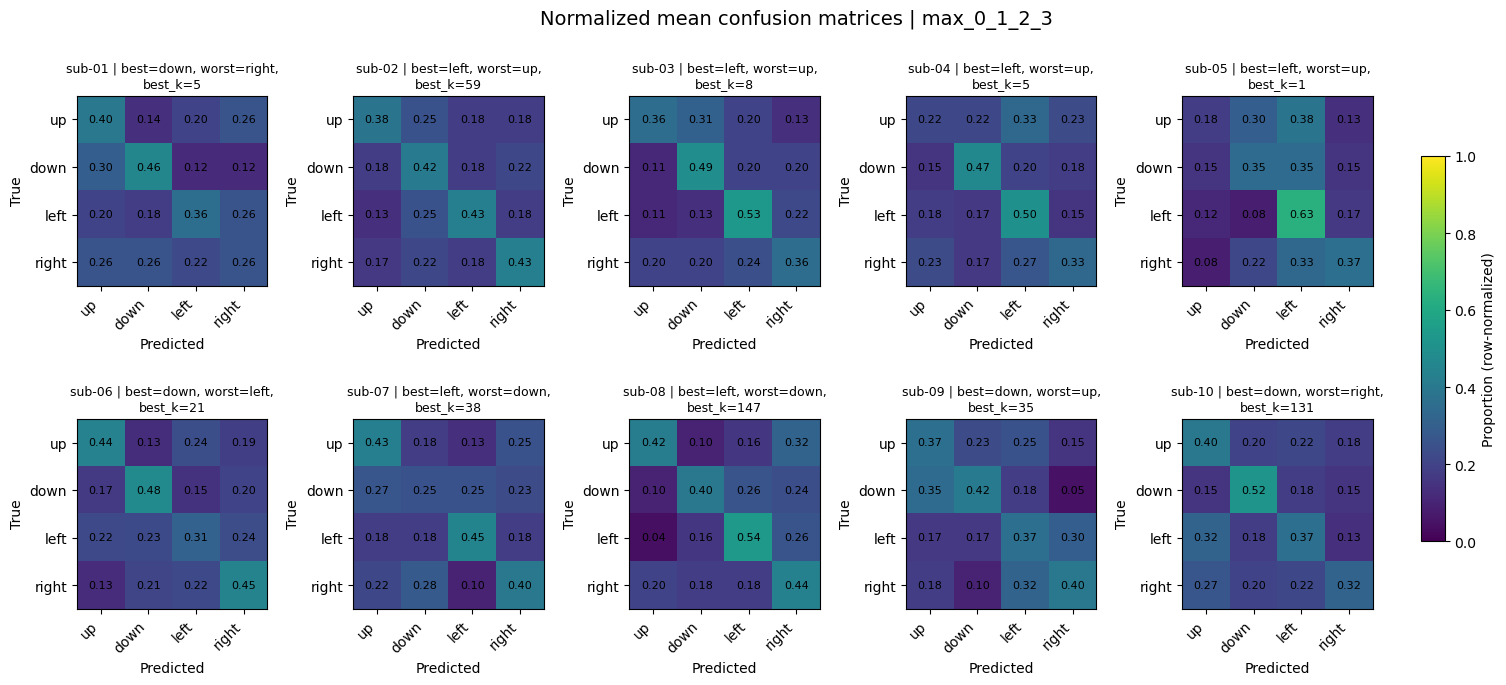

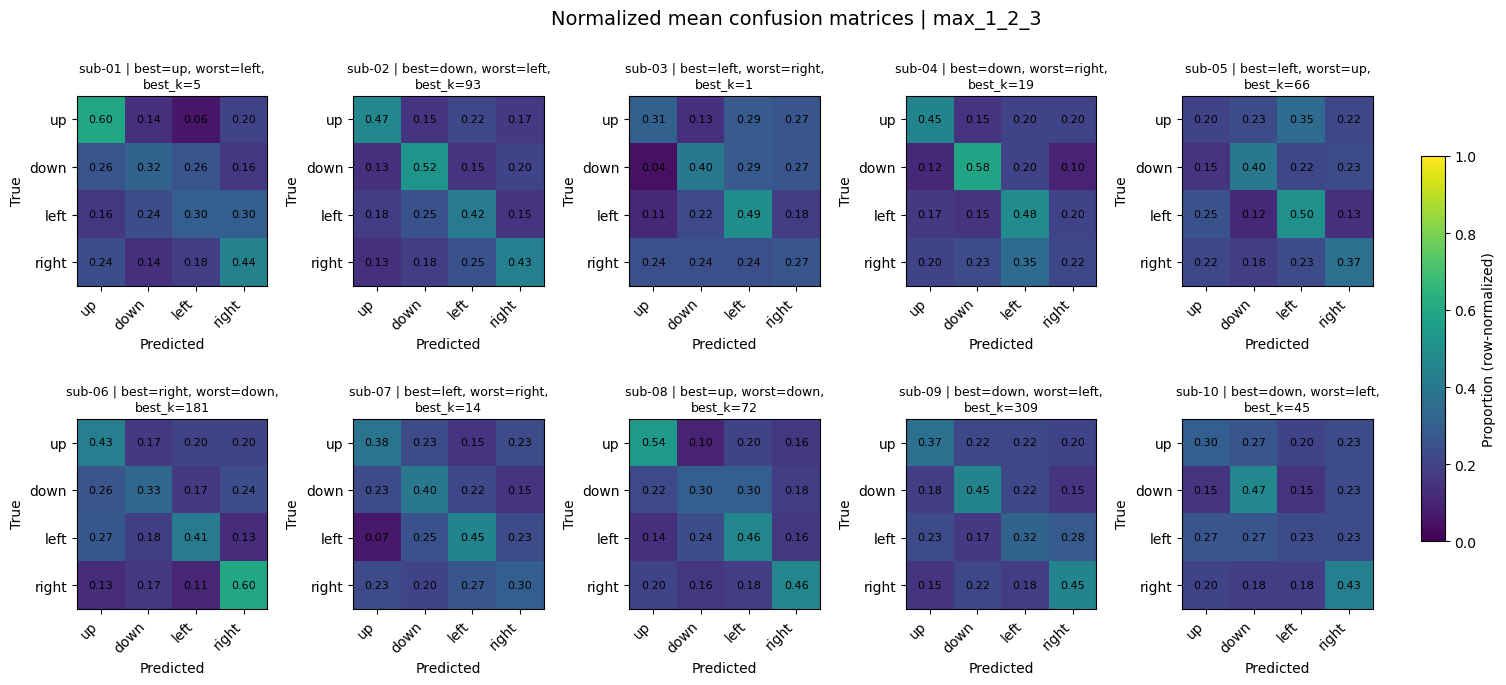

In [28]:
run_generate_confusion_matrix_for_maximum_matrix_original_flow()

<h1 style="color:darkblue; font-size:40px;">
Per-Subject Band-Wise Effect
</h1>


sub-01 ses-01 | shape original: (80, 11, 2, 128, 128)
sub-01 ses-02 | shape original: (80, 11, 2, 128, 128)
sub-01 ses-03 | shape original: (40, 11, 2, 128, 128)
sub-01 | shape após juntar sessões: (200, 11, 2, 128, 128)
sub-02 ses-01 | shape original: (80, 11, 2, 128, 128)
sub-02 ses-02 | shape original: (80, 11, 2, 128, 128)
sub-02 ses-03 | shape original: (80, 11, 2, 128, 128)
sub-02 | shape após juntar sessões: (240, 11, 2, 128, 128)
sub-03 ses-01 | shape original: (40, 11, 2, 128, 128)
sub-03 ses-02 | shape original: (80, 11, 2, 128, 128)
sub-03 ses-03 | shape original: (60, 11, 2, 128, 128)
sub-03 | shape após juntar sessões: (180, 11, 2, 128, 128)
sub-04 ses-01 | shape original: (80, 11, 2, 128, 128)
sub-04 ses-02 | shape original: (80, 11, 2, 128, 128)
sub-04 ses-03 | shape original: (80, 11, 2, 128, 128)
sub-04 | shape após juntar sessões: (240, 11, 2, 128, 128)
sub-05 ses-01 | shape original: (80, 11, 2, 128, 128)
sub-05 ses-02 | shape original: (80, 11, 2, 128, 128)
sub-05 s

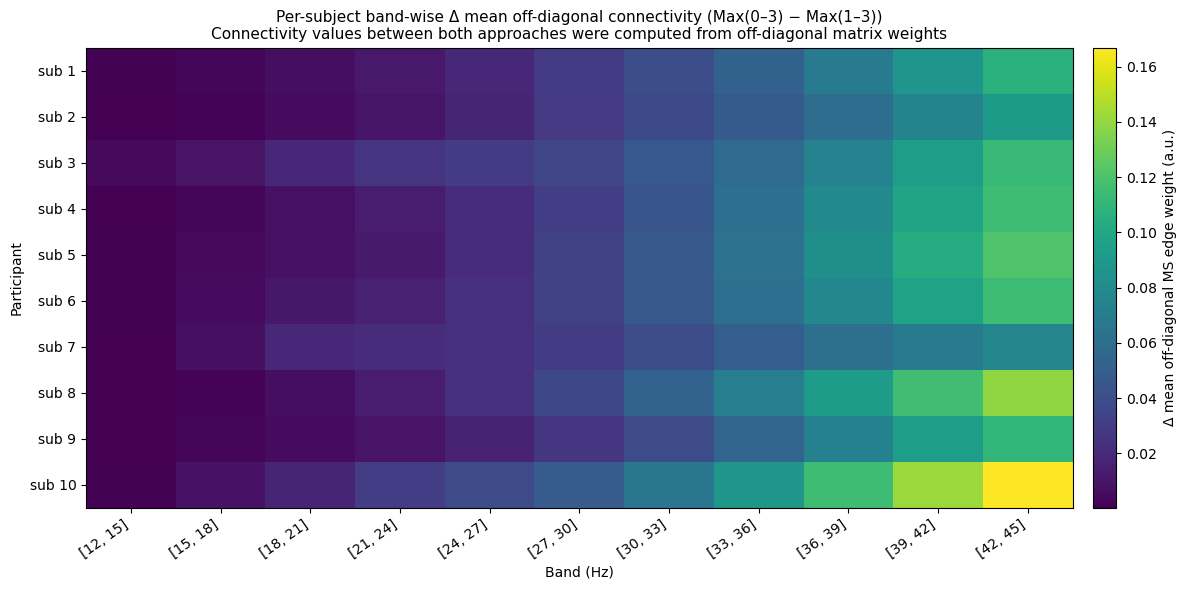

In [5]:
run_generate_per_subject_band_wise_effect()

<h1 style="color:darkblue; font-size:40px;">
Band Contribution Across Top-K Selected Features
</h1>


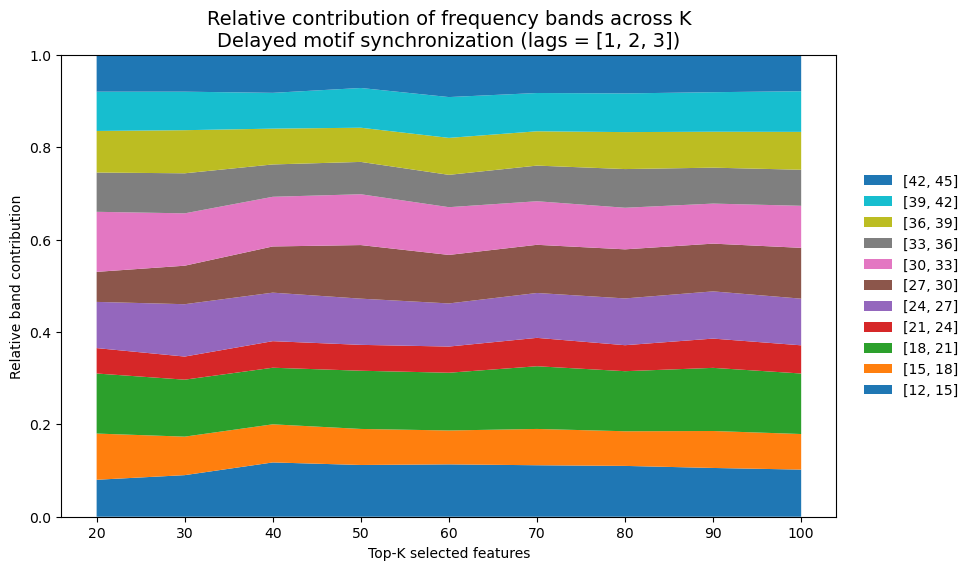

Figura salva em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/results/stage_100_generate_results_original_flow/band_contributions_across_k_features/band_contributions.png


In [2]:
plot_band_contributions_across_k_original_flow()

<h1 style="color:darkblue; font-size:40px;">
Topographic Plots
</h1>

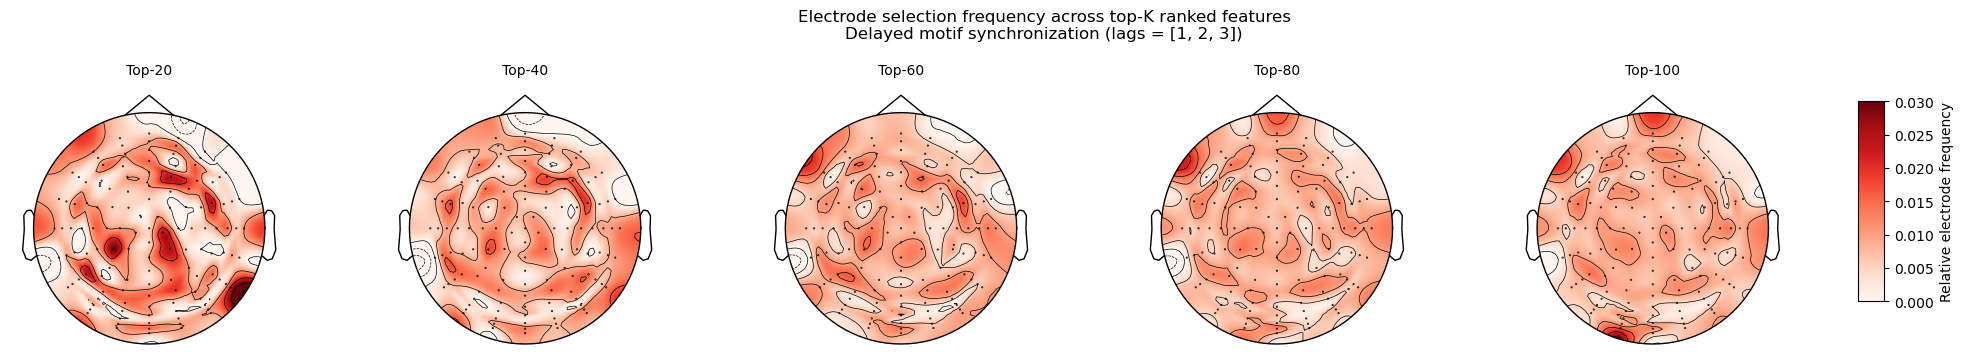

Figura salva em: /home/jobson/Documentos/Motif_and_Functional_Connectivity/motif_functional_connectivity/results/stage_100_generate_results_original_flow/generate_topographic_plot/figure_8_electrode_selection_frequency.png


In [3]:
plot_topographic_original_flow()